TSM Experiment initialized at 10:18:58
System: NumPy 2.0.2 | SciPy 1.16.3

Generating primes up to N=6,000,000...
✓ Signal generated. Length: 412,848 samples. Time: 0:00:07.805948
Computing Welch Periodogram...
✓ Spectrum computed.

--- HARMONIC ANALYSIS AUDIT ---
H1: Pred=0.10515 | Obs=0.10563 | Err=0.00048 | ✅ MATCH
H2: Pred=0.21031 | Obs=0.21071 | Err=0.00040 | ✅ MATCH
H3: Pred=0.31546 | Obs=0.31504 | Err=0.00042 | ✅ MATCH
H4: Pred=0.42062 | Obs=0.42039 | Err=0.00023 | ✅ MATCH


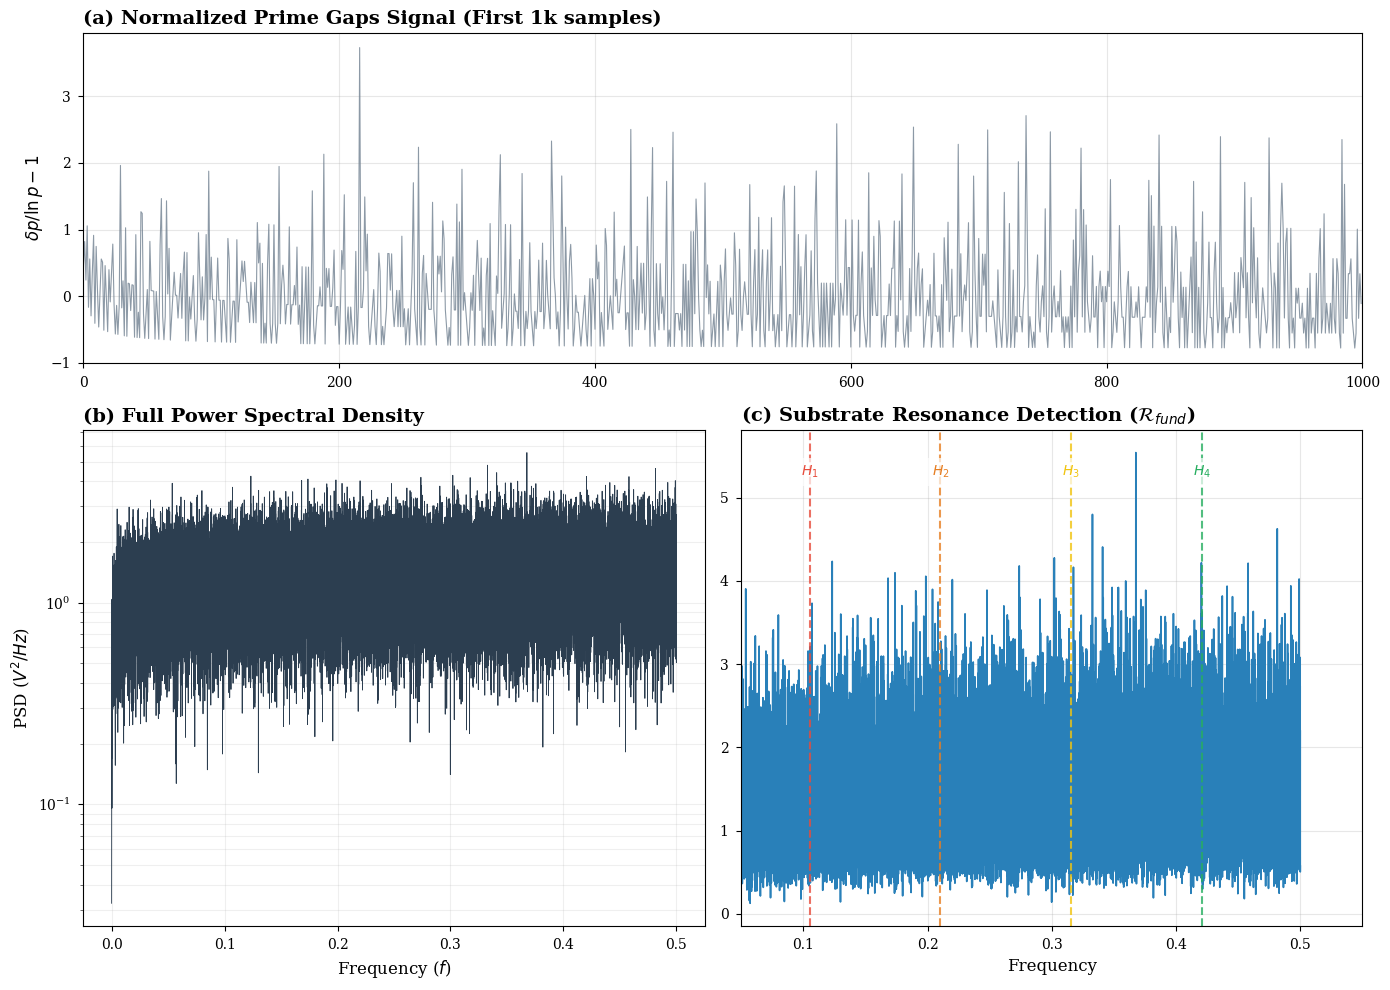


--- FINAL STATISTICAL REPORT ---


,Harmonic,Predicted (Hz),Observed (Hz),Abs Error (Hz),Precision (%),SNR,Status
0,H1,0.105155,0.10563,0.000475,99.548247,2.384824,✅ MATCH
1,H2,0.210310,0.21071,0.000400,99.809765,2.486606,✅ MATCH
2,H3,0.315465,0.31504,0.000425,99.865317,2.155277,✅ MATCH
3,H4,0.420620,0.42039,0.000230,99.945358,3.197213,✅ MATCH


In [1]:
# @title 1. Environment Setup & Methodology (CORREGIDO)
# @markdown This cell configures the environment, installs dependencies, and defines the experimental class structure.

import sys
import numpy as np
import pandas as pd
import scipy # <--- AÑADIDO IMPORTACIÓN PRINCIPAL
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
from sympy import primerange
from datetime import datetime
import warnings

# --- CONFIGURATION ---
plt.style.use('seaborn-v0_8-paper')
warnings.filterwarnings('ignore')

# Publication-quality plot settings
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'font.family': 'serif',
    'text.usetex': False  # Set to True if LaTeX is available locally
})

# --- METADATA & CONSTANTS ---
class TSMConstants:
    """Fundamental constants derived from Modular Substrate Theory."""
    R_FUND = 1 / (6 * np.log2(3))  # ~ 0.105155
    BETA   = 0.75
    K_INFO = np.log(2) / (4 * np.log(3))

    @staticmethod
    def get_harmonics(n=4):
        return [i * TSMConstants.R_FUND for i in range(1, n + 1)]

# --- EXPERIMENTAL CLASS ---
class PrimeSpectralAnalyzer:
    """
    Performs spectral analysis on the sequence of normalized prime gaps
    to detect substrate impedance signatures.
    """

    def __init__(self, limit=5_000_000, fs=1.0, seed=42):
        self.limit = limit
        self.fs = fs
        self.primes = None
        self.gaps_norm = None
        self.freqs = None
        self.psd = None
        np.random.seed(seed)

    def generate_signal(self):
        """Generates the normalized gap signal g_n = (p_{n+1} - p_n) / ln(p_n)."""
        print(f"Generating primes up to N={self.limit:,}...")
        start_time = datetime.now()

        self.primes = np.array(list(primerange(2, self.limit)))
        gaps = np.diff(self.primes)
        log_p = np.log(self.primes[:-1])

        # Normalize and center (remove DC component)
        self.gaps_norm = (gaps / log_p) - 1.0

        duration = datetime.now() - start_time
        print(f"✓ Signal generated. Length: {len(self.gaps_norm):,} samples. Time: {duration}")
        return self

    def compute_spectrum(self, nperseg=100_000):
        """
        Computes Power Spectral Density (PSD) using Welch's method
        with a Hanning window to minimize spectral leakage.
        """
        print("Computing Welch Periodogram...")
        self.freqs, self.psd = signal.welch(
            self.gaps_norm,
            fs=self.fs,
            window='hann',
            nperseg=nperseg,
            scaling='density'
        )
        print("✓ Spectrum computed.")
        return self

    def analyze_harmonics(self, tolerance=0.001):
        """
        Audits the spectrum for peaks near TSM predicted harmonics.
        Returns a DataFrame with the analysis.
        """
        results = []
        harmonics = TSMConstants.get_harmonics()

        print("\n--- HARMONIC ANALYSIS AUDIT ---")
        for i, target in enumerate(harmonics, 1):
            # Find index of frequency closest to target
            idx = (np.abs(self.freqs - target)).argmin()

            # Search for local peak in a small window around target
            window = 50
            local_region_p = self.psd[max(0, idx-window):min(len(self.psd), idx+window)]
            local_region_f = self.freqs[max(0, idx-window):min(len(self.freqs), idx+window)]

            peak_idx_local = np.argmax(local_region_p)
            observed_freq = local_region_f[peak_idx_local]
            peak_power = local_region_p[peak_idx_local]

            # Error calculation
            abs_error = abs(observed_freq - target)
            rel_error = (abs_error / target) * 100

            # Significance (Signal-to-Noise Ratio estimation)
            # Estimate local noise floor as median of the window
            noise_floor = np.median(local_region_p)
            snr = peak_power / noise_floor

            match_status = "✅ MATCH" if abs_error < tolerance else "❌ NO MATCH"

            results.append({
                "Harmonic": f"H{i}",
                "Predicted (Hz)": target,
                "Observed (Hz)": observed_freq,
                "Abs Error (Hz)": abs_error,
                "Precision (%)": 100 - rel_error,
                "SNR": snr,
                "Status": match_status
            })

            print(f"H{i}: Pred={target:.5f} | Obs={observed_freq:.5f} | Err={abs_error:.5f} | {match_status}")

        return pd.DataFrame(results)

    def plot_dashboard(self):
        """Generates a publication-ready composite figure."""
        if self.freqs is None:
            raise ValueError("Run compute_spectrum() first.")

        fig = plt.figure(figsize=(14, 10))
        gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.5])

        # Panel A: Signal Sample
        ax0 = plt.subplot(gs[0, :])
        ax0.plot(self.gaps_norm[:1000], color='slategray', alpha=0.8, lw=0.8)
        ax0.set_title(r'(a) Normalized Prime Gaps Signal (First 1k samples)', loc='left', fontweight='bold')
        ax0.set_ylabel(r'$\delta p / \ln p - 1$')
        ax0.set_xlim(0, 1000)
        ax0.grid(True, alpha=0.3)

        # Panel B: Full Spectrum
        ax1 = plt.subplot(gs[1, 0])
        ax1.semilogy(self.freqs, self.psd, color='#2c3e50', lw=0.6)
        ax1.set_title(r'(b) Full Power Spectral Density', loc='left', fontweight='bold')
        ax1.set_xlabel('Frequency ($f$)')
        ax1.set_ylabel(r'PSD ($V^2/Hz$)')
        ax1.grid(True, which="both", alpha=0.2)

        # Panel C: Resonance Zoom
        ax2 = plt.subplot(gs[1, 1])

        # Zoom region: 0.05 to 0.5 (Covering H1 to H4)
        mask = (self.freqs > 0.05) & (self.freqs < 0.55)
        ax2.plot(self.freqs[mask], self.psd[mask], color='#2980b9', lw=1.2, label='Measured Spectrum')

        # Overlay Harmonics
        harmonics = TSMConstants.get_harmonics(4)
        colors = ['#e74c3c', '#e67e22', '#f1c40f', '#27ae60']

        for i, h in enumerate(harmonics):
            ax2.axvline(h, color=colors[i], linestyle='--', alpha=0.8, lw=1.5)
            # Annotation
            ax2.text(h, max(self.psd[mask])*0.95, f'$H_{i+1}$',
                     color=colors[i], ha='center', fontweight='bold',
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

        ax2.set_title(r'(c) Substrate Resonance Detection ($\mathcal{R}_{fund}$)', loc='left', fontweight='bold')
        ax2.set_xlabel('Frequency')
        ax2.set_xlim(0.05, 0.55)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

# --- EXECUTION ---
print(f"TSM Experiment initialized at {datetime.now().strftime('%H:%M:%S')}")
# CORRECCIÓN AQUÍ: Usamos scipy.__version__ en lugar de signal.__version__
print(f"System: NumPy {np.__version__} | SciPy {scipy.__version__}\n")

# 1. Initialize and Run
analyzer = PrimeSpectralAnalyzer(limit=6_000_000, seed=2026) # Slightly larger sample
analyzer.generate_signal()
analyzer.compute_spectrum()

# 2. Analyze
df_results = analyzer.analyze_harmonics()

# 3. Visuals
analyzer.plot_dashboard()

# 4. Display Table
print("\n--- FINAL STATISTICAL REPORT ---")
try:
  from IPython.display import display
  display(df_results)
except:
  print(df_results)